In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'alzheimers-multiclass-dataset-equal-and-augmented' dataset.
Path to dataset files: /kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented


In [ ]:

import os
data_path = os.path.join(path, "combined_images")

print(os.listdir(data_path))

['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'MildDemented']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 35200 images belonging to 4 classes.
Found 8800 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Load base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
base_model.trainable = False

# Build model
model_mobilenet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(4, activation='softmax')
])

model_mobilenet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_mobilenet.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history_mobilenet = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.6084 - loss: 0.9825
Epoch 1: val_accuracy improved from None to 0.76773, saving model to best_mobilenet.keras

Epoch 1: finished saving model to best_mobilenet.keras
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 300s 254ms/step - accuracy: 0.6638 - loss: 0.7966 - val_accuracy: 0.7677 - val_loss: 0.5489
Epoch 2/10
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7430 - loss: 0.5955
Epoch 2: val_accuracy improved from 0.76773 to 0.79636, saving model to best_mobilenet.keras

Epoch 2: finished saving model to best_mobilenet.keras
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 73s 66ms/step - accuracy: 0.7495 - loss: 0.5821 - val_accuracy: 0.7964 - val_loss: 0.4741
Epoch 3/10
1099/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7773 - loss: 0.5125
Epoch 3: val_accuracy improved from 0.79636 to 0.84295, saving model to best_mobilenet.keras

Epoch 3: finished saving model to best_mobilenet.keras
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 77s 70ms/step

275/275 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step


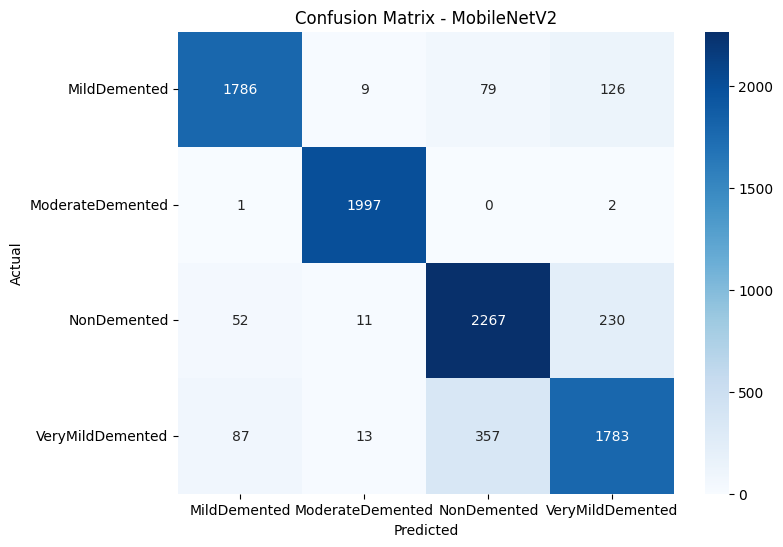

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = model_mobilenet.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = val_data.classes

# Class names
class_names = list(val_data.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = model_mobilenet.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

print("Classification Report - MobileNetV2")
print("=================================================")
print(classification_report(y_true, y_pred_classes))

275/275 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step
Classification Report - MobileNetV2
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2000
           1       0.98      1.00      0.99      2000
           2       0.84      0.89      0.86      2560
           3       0.83      0.80      0.81      2240

    accuracy                           0.89      8800
   macro avg       0.90      0.89      0.89      8800
weighted avg       0.89      0.89      0.89      8800



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print("========================================")
print("   KPI Matrix - MobileNetV2")
print("========================================")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print("========================================")

   KPI Matrix - MobileNetV2
Accuracy  : 89.01%
Precision : 89.03%
Recall    : 89.01%
F1 Score  : 88.98%


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


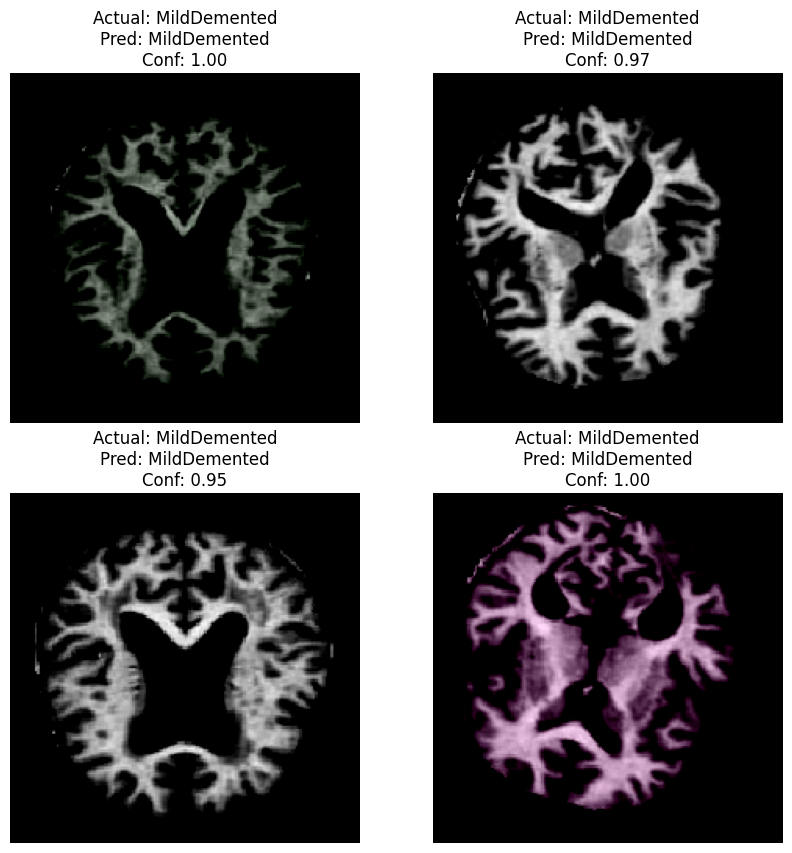

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get validation batch
x_batch, y_batch = next(val_data)

classes = list(train_data.class_indices.keys())

plt.figure(figsize=(10,10))

for i in range(4):
    img = x_batch[i]
    true_label = np.argmax(y_batch[i])

    pred = model_mobilenet.predict(np.expand_dims(img, axis=0))
    pred_label = np.argmax(pred)
    confidence = np.max(pred)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(f"Actual: {classes[true_label]}\nPred: {classes[pred_label]}\nConf: {confidence:.2f}")
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


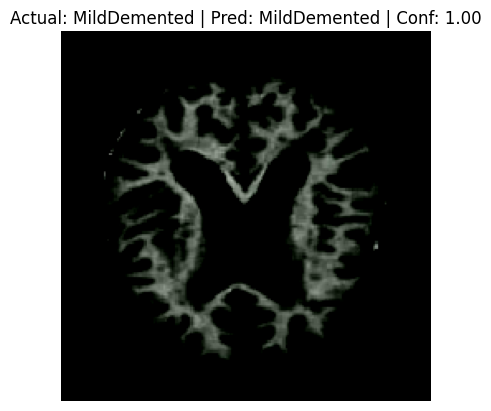

In [ ]:
img = x_batch[0]
true_label = np.argmax(y_batch[0])

pred = model_mobilenet.predict(np.expand_dims(img, axis=0))
pred_label = np.argmax(pred)
confidence = np.max(pred)

plt.imshow(img)
plt.title(f"Actual: {classes[true_label]} | Pred: {classes[pred_label]} | Conf: {confidence:.2f}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


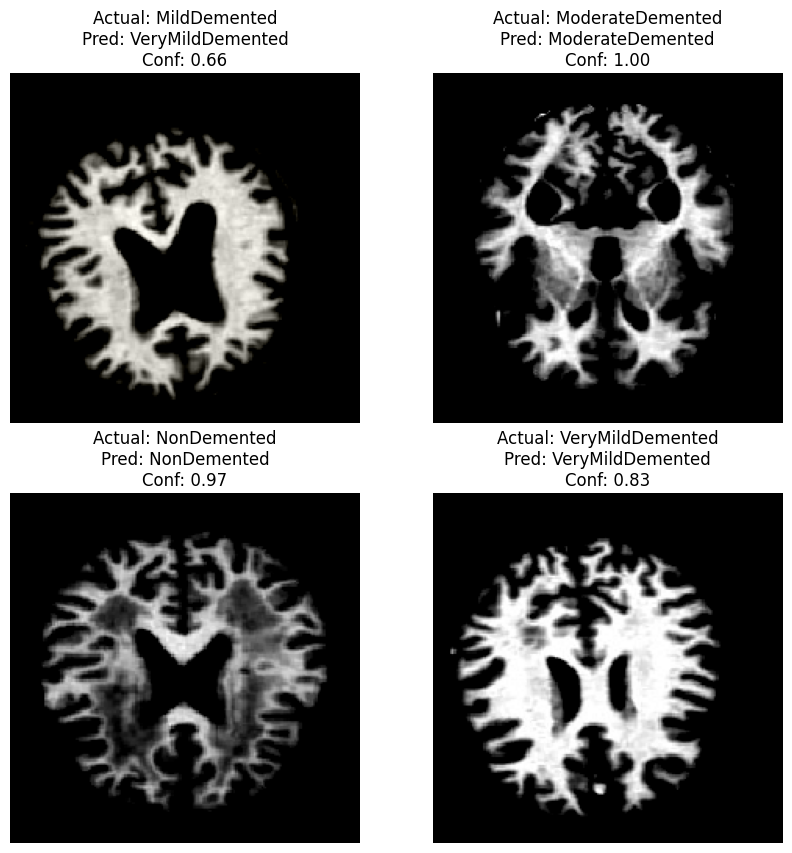

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = list(train_data.class_indices.keys())

plt.figure(figsize=(10,10))

for i, class_name in enumerate(classes):
    found = False

    for x_batch, y_batch in val_data:
        for j in range(len(y_batch)):
            if np.argmax(y_batch[j]) == i:
                img = x_batch[j]
                true_label = i

                pred = model_mobilenet.predict(np.expand_dims(img, axis=0))
                pred_label = np.argmax(pred)
                confidence = np.max(pred)

                plt.subplot(2,2,i+1)
                plt.imshow(img)
                plt.title(f"Actual: {classes[true_label]}\nPred: {classes[pred_label]}\nConf: {confidence:.2f}")
                plt.axis('off')

                found = True
                break
        if found:
            break

plt.show()